<a href="https://colab.research.google.com/github/sasvi123/Neural_Network/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy WITHOUT Outliers: 0.9833


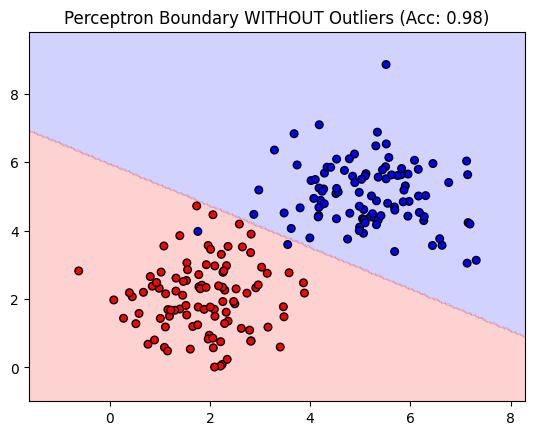

Accuracy WITH Outliers: 0.9344


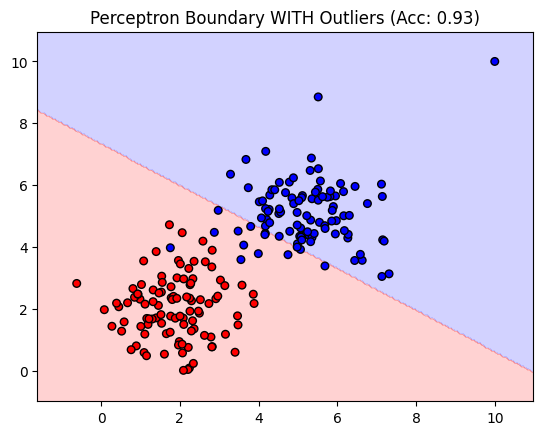

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set seed for reproducible distribution results
np.random.seed(42)


# Step 1: Generate Data (Gaussian Distributions)

mean1, mean2 = [2, 2], [5, 5]
cov = [[1, 0], [0, 1]] # Identity matrix for variance

class1 = np.random.multivariate_normal(mean1, cov, 100) # Label: 1
class2_clean = np.random.multivariate_normal(mean2, cov, 100) # Label: -1

# Generate dataset WITHOUT outlier
X_clean = np.vstack([class1, class2_clean])
y_clean = np.hstack([np.ones(100), -np.ones(100)])

# Generate dataset WITH outlier
class2_outlier = np.vstack([class2_clean, [10, 10]]) # Extreme point added
X_outlier = np.vstack([class1, class2_outlier])
y_outlier = np.hstack([np.ones(100), -np.ones(101)])


# Step 2 & 3: Function to Train and Evaluate

def evaluate_dataset(X, y, title_suffix):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy {title_suffix}: {acc:.4f}")

    # Boundary plotting setup
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=30, cmap='bwr')
    plt.title(f"Perceptron Boundary {title_suffix} (Acc: {acc:.2f})")
    plt.show()

evaluate_dataset(X_clean, y_clean, "WITHOUT Outliers")
evaluate_dataset(X_outlier, y_outlier, "WITH Outliers")